# dots.ocr — SageMaker 기반 문서 분석 → Markdown 저장

**파이프라인:**  
`PDF/이미지 입력` → `페이지 이미지 변환` → `SageMaker OCR (병렬)` → `레이아웃 JSON 파싱` → `Markdown 조립` → `파일 저장`

**특징:**
- EC2 인스턴스 롤(`seokhyeon_ec2_iamRole`)로 SageMaker 호출 — IAM 유저 키 불필요
- `dots_ocr_deploy/utils/` 모듈 재사용
- 페이지별 bbox 시각화 이미지 저장 (옵션)
- `{문서명}.md` / `{문서명}_nohf.md` (헤더·푸터 제외) 두 버전 저장

## Cell 1. Config — 여기만 수정하세요

In [33]:
# ============================================================
#  AWS / SageMaker
# ============================================================
REGION        = "ap-northeast-2"
ENDPOINT_NAME = "dots-mocr-vllm-endpoint"
MODEL_NAME    = "model"       # vllm serve --served-model-name 값

# max_model_len=8192 이 전체 컨텍스트 한도입니다.
# 이미지 토큰 + 프롬프트 텍스트 토큰 + 출력 토큰 <= 8192
# → 이미지/프롬프트가 ~3000-4000 토큰을 사용하므로 출력은 4096 이하로 설정
MAX_TOKENS    = 4096
TEMPERATURE   = 0.1

# ============================================================
#  입력 / 출력
# ============================================================
INPUT_PATH = "./2143865.pdf"   # PDF 또는 이미지(.jpg/.png) 경로
OUTPUT_DIR = "./output"       # 결과 저장 루트

# ============================================================
#  처리 옵션
# ============================================================
DPI          = 200    # PDF 렌더링 DPI (높을수록 정확, 느림)
NUM_THREADS  = 4      # 병렬 페이지 처리 스레드 수

# PROMPT_MODE 선택:
#   'prompt_layout_all_en'  — 레이아웃 감지 + OCR → JSON + MD (권장)
#   'prompt_ocr'            — 텍스트 추출만 (빠름)
#   'prompt_layout_only_en' — 레이아웃 bbox 감지만
PROMPT_MODE   = "prompt_layout_all_en"

SHOW_BBOX_VIZ = True   # 레이아웃 bbox 시각화 이미지 저장
SAVE_JSON     = True   # 페이지별 JSON 저장

print("설정 완료")
print(f"  endpoint   : {ENDPOINT_NAME}")
print(f"  max_tokens : {MAX_TOKENS}  (컨텍스트 한도 8192, 입력+출력 합계 이하 유지)")
print(f"  입력       : {INPUT_PATH}")
print(f"  출력       : {OUTPUT_DIR}")
print(f"  DPI        : {DPI}  |  threads: {NUM_THREADS}  |  mode: {PROMPT_MODE}")

설정 완료
  endpoint   : dots-mocr-vllm-endpoint
  max_tokens : 4096  (컨텍스트 한도 8192, 입력+출력 합계 이하 유지)
  입력       : ./2143865.pdf
  출력       : ./output
  DPI        : 200  |  threads: 4  |  mode: prompt_layout_all_en


## Cell 2. 패키지 임포트 & SageMaker 클라이언트 초기화

In [34]:
import sys
import pathlib

# ── 경로 설정
# dots_ocr_deploy/ 디렉터리와 그 부모(pdf-parser/)를 모두 추가
NOTEBOOK_DIR = pathlib.Path(".").resolve()
PARENT_DIR   = NOTEBOOK_DIR.parent
for p in [str(NOTEBOOK_DIR), str(PARENT_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ── 표준 라이브러리
import io
import re
import ast
import json
import base64
import datetime
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter

# ── 3rd-party
import boto3
from PIL import Image
from tqdm.notebook import tqdm
from IPython.display import display, Markdown

# ── dots_ocr_deploy 내부 모듈
from utils.prompts         import dict_promptmode_to_prompt
from utils.layout_utils    import post_process_output, draw_layout_on_image
from utils.format_transformer import layoutjson2md
from utils.doc_utils       import load_images_from_pdf
from utils.image_utils     import PILimage_to_base64, fetch_image

# ── boto3 세션: EC2 인스턴스 롤 사용
# ~/.aws/credentials 의 IAM 유저 키 대신 EC2 롤 임시 자격증명을 사용합니다.
# (profile 'ec2_role' → credential_source = Ec2InstanceMetadata)
session = boto3.Session(profile_name="ec2_role", region_name=REGION)
sm_rt   = session.client("sagemaker-runtime")

# ── 자격증명 및 엔드포인트 확인
sts = session.client("sts")
sm  = session.client("sagemaker")
try:
    identity = sts.get_caller_identity()
    print(f"✅ 자격증명 : {identity['Arn']}")
except Exception as e:
    print(f"❌ 자격증명 오류: {e}")

try:
    ep = sm.describe_endpoint(EndpointName=ENDPOINT_NAME)
    status = ep["EndpointStatus"]
    icon   = "🟢" if status == "InService" else "🔴"
    print(f"{icon} 엔드포인트 : {ENDPOINT_NAME}  [{status}]")
    if status != "InService":
        print("  ⚠️  InService 상태가 아닙니다. OCR 호출이 실패할 수 있습니다.")
except Exception as e:
    print(f"❌ 엔드포인트 확인 실패: {e}")

✅ 자격증명 : arn:aws:sts::847776736936:assumed-role/seokhyeon_ec2_iamRole/i-0c64de1663fcc6477
🟢 엔드포인트 : dots-mocr-vllm-endpoint  [InService]


## Cell 3. 문서 로드 — PDF / 이미지 → 페이지 이미지

PDF 로드 중: 2143865.pdf  (DPI=200)
총 7 페이지 로드 완료 (0s)

첫 페이지 미리보기 (1654×2339px):


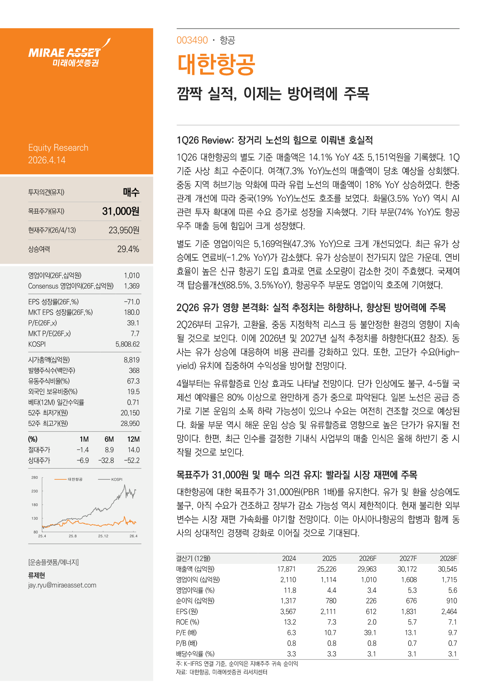

In [35]:
input_path = Path(INPUT_PATH)
assert input_path.exists(), f"파일을 찾을 수 없습니다: {input_path.resolve()}"

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

t0 = datetime.datetime.now()

if input_path.suffix.lower() == ".pdf":
    print(f"PDF 로드 중: {input_path}  (DPI={DPI})")
    page_images = load_images_from_pdf(str(input_path), dpi=DPI)
    print(f"총 {len(page_images)} 페이지 로드 완료 ({(datetime.datetime.now()-t0).seconds}s)")
elif input_path.suffix.lower() in IMAGE_EXTS:
    page_images = [Image.open(str(input_path)).convert("RGB")]
    print(f"이미지 1장 로드: {input_path}")
else:
    raise ValueError(f"지원하지 않는 형식: {input_path.suffix}  (PDF 또는 {IMAGE_EXTS})")

# 첫 페이지 미리보기
preview = page_images[0].copy()
preview.thumbnail((500, 700))
print(f"\n첫 페이지 미리보기 ({page_images[0].size[0]}×{page_images[0].size[1]}px):")
display(preview)

## Cell 4. SageMaker 호출 함수 정의

In [36]:
def call_sagemaker(image: Image.Image, prompt: str, max_tokens: int = None) -> str | None:
    """PIL 이미지 + 프롬프트 → SageMaker vLLM 엔드포인트 호출 → 응답 텍스트

    컨텍스트 초과(400) 발생 시 max_tokens를 절반으로 줄여 1회 재시도합니다.
    """
    if max_tokens is None:
        max_tokens = MAX_TOKENS

    buf = io.BytesIO()
    image.save(buf, format="PNG")
    img_b64 = base64.b64encode(buf.getvalue()).decode()

    def _invoke(mt: int):
        payload = {
            "model": MODEL_NAME,
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "image_url",
                            "image_url": {"url": f"data:image/png;base64,{img_b64}"},
                        },
                        {
                            "type": "text",
                            "text": f"<|img|><|imgpad|><|endofimg|>{prompt}",
                        },
                    ],
                }
            ],
            "max_tokens": mt,
            "temperature": TEMPERATURE,
        }
        response = sm_rt.invoke_endpoint(
            EndpointName=ENDPOINT_NAME,
            ContentType="application/json",
            Body=json.dumps(payload),
        )
        raw = response["Body"].read().decode("utf-8")
        result = json.loads(raw)

        if isinstance(result, dict) and "choices" in result:
            return result["choices"][0]["message"]["content"]
        if isinstance(result, dict) and "generated_text" in result:
            inner = result["generated_text"]
            try:
                parsed = ast.literal_eval(inner)
                return parsed["choices"][0]["message"]["content"]
            except Exception:
                return inner
        return str(result)

    # 1차 시도
    try:
        return _invoke(max_tokens)
    except Exception as e:
        err = str(e)
        # 컨텍스트 초과 → max_tokens 절반으로 줄여 재시도
        if "context length" in err or "max_tokens" in err:
            retry_mt = max_tokens // 2
            print(f"  [재시도] max_tokens {max_tokens} → {retry_mt} (컨텍스트 초과)")
            try:
                return _invoke(retry_mt)
            except Exception as e2:
                print(f"[SageMaker 오류] {e2}")
                return None
        print(f"[SageMaker 오류] {e}")
        return None


def process_page(page_idx: int, origin_image: Image.Image, prompt_mode: str) -> dict:
    """한 페이지 이미지 → OCR 결과 dict"""
    image  = fetch_image(origin_image)
    prompt = dict_promptmode_to_prompt[prompt_mode]
    response = call_sagemaker(image, prompt)

    result = {
        "page_idx":     page_idx,
        "origin_image": origin_image,
        "raw_response": response,
    }

    if response is None:
        result.update({"cells": [], "md": "", "md_nohf": "", "error": "응답 없음"})
        return result

    if prompt_mode in ("prompt_layout_all_en", "prompt_layout_only_en"):
        cells, filtered = post_process_output(response, prompt_mode, origin_image, image)
        result["cells"]    = cells if not filtered else []
        result["filtered"] = filtered

        if prompt_mode != "prompt_layout_only_en" and not filtered:
            result["md"]      = layoutjson2md(origin_image, cells, text_key="text")
            result["md_nohf"] = layoutjson2md(origin_image, cells, text_key="text", no_page_hf=True)
        else:
            result["md"]      = cells if filtered else ""
            result["md_nohf"] = result["md"]
    else:
        result.update({"cells": [], "md": response, "md_nohf": response})

    return result


print("함수 정의 완료")
print(f"  call_sagemaker() : 컨텍스트 초과 시 max_tokens 절반으로 자동 재시도")
print(f"  process_page()   : 페이지 단위 OCR 처리")

함수 정의 완료
  call_sagemaker() : 컨텍스트 초과 시 max_tokens 절반으로 자동 재시도
  process_page()   : 페이지 단위 OCR 처리


## Cell 5. OCR 병렬 처리 — 페이지별 SageMaker 호출

In [37]:
total_pages  = len(page_images)
page_results = [None] * total_pages
workers      = min(NUM_THREADS, total_pages)

print(f"총 {total_pages} 페이지를 {workers} 스레드로 처리합니다...")
print(f"Prompt mode : {PROMPT_MODE}")
print(f"Endpoint    : {ENDPOINT_NAME}\n")

ocr_start = datetime.datetime.now()

with ThreadPoolExecutor(max_workers=workers) as executor:
    future_to_idx = {
        executor.submit(process_page, i, img, PROMPT_MODE): i
        for i, img in enumerate(page_images)
    }
    with tqdm(total=total_pages, desc="OCR 진행") as pbar:
        for future in as_completed(future_to_idx):
            idx = future_to_idx[future]
            try:
                page_results[idx] = future.result()
            except Exception as e:
                print(f"[오류] 페이지 {idx+1}: {e}")
                page_results[idx] = {
                    "page_idx":     idx,
                    "origin_image": page_images[idx],
                    "cells":        [],
                    "md":           "",
                    "md_nohf":      "",
                    "error":        str(e),
                }
            pbar.update(1)

elapsed  = (datetime.datetime.now() - ocr_start).seconds
success  = sum(1 for r in page_results if r and not r.get("error"))
filtered = sum(1 for r in page_results if r and r.get("filtered"))
errors   = sum(1 for r in page_results if r and r.get("error"))

print(f"\n완료: {success}/{total_pages} 성공  |  {filtered}개 JSON fallback  |  {errors}개 오류  |  {elapsed}초")

총 7 페이지를 4 스레드로 처리합니다...
Prompt mode : prompt_layout_all_en
Endpoint    : dots-mocr-vllm-endpoint



OCR 진행:   0%|          | 0/7 [00:00<?, ?it/s]

cells post process error: Expecting ',' delimiter: line 1 column 4947 (char 4946), when using prompt_layout_all_en
🔧 Cleaning String data - Case 0
  Original length: 4,946
    ✂️ Truncated the last incomplete element, length reduced from 4,946 to 4,922
    📊 Found 15 dict objects
    ✅ No duplicate dict objects found
  ✅ Cleaning complete: 15 objects
    📊 Original data length: 15
    ✅ No category-text pairs or bboxes found exceeding the duplication threshold
cells post process error: Unterminated string starting at: line 1 column 4768 (char 4767), when using prompt_layout_all_en
🔧 Cleaning String data - Case 0
  Original length: 4,854
    ✂️ Truncated the last incomplete element, length reduced from 4,854 to 4,703
    📊 Found 9 dict objects
    ✅ No duplicate dict objects found
  ✅ Cleaning complete: 9 objects
    📊 Original data length: 9
    ✅ No category-text pairs or bboxes found exceeding the duplication threshold

완료: 7/7 성공  |  2개 JSON fallback  |  0개 오류  |  141초


## Cell 6. Markdown 조립

In [38]:
stem = input_path.stem
parts, parts_nohf = [], []

for r in page_results:
    page_no = r["page_idx"] + 1

    # 페이지 구분선 + 페이지 번호 태그
    parts.append(f"\n\n<page-{page_no:03d}>\n")
    parts.append(r.get("md") or "")
    parts.append(f"\n</page-{page_no:03d}>")

    parts_nohf.append(f"\n\n<page-{page_no:03d}>\n")
    parts_nohf.append(r.get("md_nohf") or r.get("md") or "")
    parts_nohf.append(f"\n</page-{page_no:03d}>")

final_md      = "\n".join(parts).strip()
final_md_nohf = "\n".join(parts_nohf).strip()

print(f"Markdown 조립 완료")
print(f"  전체(헤더·푸터 포함) : {len(final_md):,} 자")
print(f"  헤더·푸터 제외       : {len(final_md_nohf):,} 자")
print(f"\n--- 첫 500자 미리보기 ---")
print(final_md[:500])

Markdown 조립 완료
  전체(헤더·푸터 포함) : 581,403 자
  헤더·푸터 제외       : 581,135 자

--- 첫 500자 미리보기 ---
<page-001>

MIRAE ASSET
미래에셋증권

Equity Research
2026.4.14

<table><tr><td>투자의견(유지)</td><td>매수</td></tr><tr><td>목표주가(유지)</td><td>31,000원</td></tr><tr><td>현재주가(26/4/13)</td><td>23,950원</td></tr><tr><td>상승여력</td><td>29.4%</td></tr></table>

<table><tr><td>영업이익(26F,십억원)</td><td>1,010</td></tr><tr><td>Consensus 영업이익(26F,십억원)</td><td>1,369</td></tr><tr><td>EPS 성장률(26F,%)</td><td>-71.0</td></tr><tr><td>MKT EPS 성장률(26F,%)</td><td>180.0</td></tr><tr><td>P/E(26F,x)</td><td>39.1</td></tr><tr><td>MKT P/E(26


## Cell 7. 결과 저장

In [39]:
out_dir = Path(OUTPUT_DIR) / stem
out_dir.mkdir(parents=True, exist_ok=True)

# ── 1. Markdown 저장
md_path      = out_dir / f"{stem}.md"
md_nohf_path = out_dir / f"{stem}_nohf.md"
md_path.write_text(final_md,      encoding="utf-8")
md_nohf_path.write_text(final_md_nohf, encoding="utf-8")
print(f"✅ Markdown 저장:")
print(f"   {md_path}")
print(f"   {md_nohf_path}")

# ── 2. 페이지별 JSON 저장 (옵션)
if SAVE_JSON:
    json_dir = out_dir / "json"
    json_dir.mkdir(exist_ok=True)
    saved_json = 0
    for r in page_results:
        cells = r.get("cells", [])
        if cells:
            p = json_dir / f"{stem}_page_{r['page_idx']+1:03d}.json"
            p.write_text(json.dumps(cells, ensure_ascii=False, indent=2), encoding="utf-8")
            saved_json += 1
    print(f"✅ JSON 저장: {json_dir}  ({saved_json}페이지)")

# ── 3. bbox 시각화 이미지 저장 (옵션)
if SHOW_BBOX_VIZ and PROMPT_MODE in ("prompt_layout_all_en", "prompt_layout_only_en"):
    viz_dir = out_dir / "layout_viz"
    viz_dir.mkdir(exist_ok=True)
    saved_viz = 0
    for r in page_results:
        cells = r.get("cells", [])
        if cells and not r.get("filtered"):
            try:
                viz = draw_layout_on_image(r["origin_image"], cells)
                viz_path = viz_dir / f"{stem}_page_{r['page_idx']+1:03d}_layout.jpg"
                viz.save(str(viz_path))
                saved_viz += 1
            except Exception as e:
                print(f"  [시각화 오류] 페이지 {r['page_idx']+1}: {e}")
    print(f"✅ 레이아웃 시각화 저장: {viz_dir}  ({saved_viz}페이지)")

print(f"\n📂 출력 디렉터리: {out_dir.resolve()}")

✅ Markdown 저장:
   output/2143865/2143865.md
   output/2143865/2143865_nohf.md
✅ JSON 저장: output/2143865/json  (5페이지)
✅ 레이아웃 시각화 저장: output/2143865/layout_viz  (5페이지)

📂 출력 디렉터리: /home/ubuntu/pdf-parser/dots_ocr_deploy/output/2143865


## Cell 8. 인라인 미리보기

In [40]:
PREVIEW_PAGES = 3  # 미리볼 최대 페이지 수

for r in page_results[:PREVIEW_PAGES]:
    page_no = r["page_idx"] + 1
    md_text = r.get("md_nohf") or r.get("md") or "*(OCR 결과 없음)*"

    # base64 인코딩 이미지는 미리보기에서 생략 (렌더링 지연 방지)
    md_text = re.sub(r"!\[\]\(data:image[^)]+\)", "*(이미지 생략)*", md_text)

    error_note = f"\n\n> ⚠️ 오류: {r['error']}" if r.get("error") else ""
    display(Markdown(f"---\n## Page {page_no}{error_note}\n{md_text}"))

---
## Page 1
<table><tr><td>투자의견(유지)</td><td>매수</td></tr><tr><td>목표주가(유지)</td><td>31,000원</td></tr><tr><td>현재주가(26/4/13)</td><td>23,950원</td></tr><tr><td>상승여력</td><td>29.4%</td></tr></table>

<table><tr><td>영업이익(26F,십억원)</td><td>1,010</td></tr><tr><td>Consensus 영업이익(26F,십억원)</td><td>1,369</td></tr><tr><td>EPS 성장률(26F,%)</td><td>-71.0</td></tr><tr><td>MKT EPS 성장률(26F,%)</td><td>180.0</td></tr><tr><td>P/E(26F,x)</td><td>39.1</td></tr><tr><td>MKT P/E(26F,x)</td><td>7.7</td></tr><tr><td>KOSPI</td><td>5,808.62</td></tr><tr><td>시가총액(십억원)</td><td>8,819</td></tr><tr><td>발행주식수(백만주)</td><td>368</td></tr><tr><td>유동주식비율(%)</td><td>67.3</td></tr><tr><td>외국인 보유비중(%)</td><td>19.5</td></tr><tr><td>베타(12M) 일간수익률</td><td>0.71</td></tr><tr><td>52주 최저가(원)</td><td>20,150</td></tr><tr><td>52주 최고가(원)</td><td>28,950</td></tr><tr><td>(%)</td><td>1M</td><td>6M</td><td>12M</td></tr><tr><td>절대주가</td><td>-1.4</td><td>8.9</td><td>14.0</td></tr><tr><td>상대주가</td><td>-6.9</td><td>-32.8</td><td>-52.2</td></tr></table>

*(이미지 생략)*

[운송플랫폼/에너지]

류제현
jay.ryu@miraeasset.com

# 대한항공

## 깜짝 실적, 이제는 방어력에 주목

### 1Q26 Review: 장거리 노선의 힘으로 이交낸 호실적

1Q26 대한항공의 별도 기준 매출액은 14.1% YoY 4조 5,151억원을 기록했다. 1Q 기준 사상 최고 수준이다. 여객(7.3% YoY)노선의 매출액이 당초 예상을 상회했다. 중동 지역 허브기능 약화에 따라 유럽 노선의 매출액이 18% YoY 상승하였다. 한중 관계 개선에 따라 중국(19% YoY)노선도 호조를 보였다. 화물(3.5% YoY) 역시 AI 관련 투자 확대에 따른 수요 증가로 성장을 지속했다. 기타 부문(74% YoY)도 항공 우주 매출 등에 힘입어 크게 성장했다.

별도 기준 영업이익은 5,169억원(47.3% YoY)으로 크게 개선되었다. 최근 유가 상승에도 연료비(-1.2% YoY)가 감소했다. 유가 상승분이 전가되지 않은 가운데, 연비 효율이 높은 신규 항공기 도입 효과로 연료 소모량이 감소한 것이 주효했다. 국제여객 탑승률개선(88.5%, 3.5% YoY), 항공우주 부문도 영업이익 호조에 기여했다.

### 2Q26 유가 영향 본격화: 실적 추정치는 하향하나, 향상된 방어력에 주목

2Q26부터 고유가, 고환율, 중동 지정학적 리스크 등 불안정한 환경의 영향이 지속될 것으로 보인다. 이에 2026년 및 2027년 실적 추정치를 하향한다(표2 참조). 동사는 유가 상승에 대응하여 비용 관리를 강화하고 있다. 또한, 고단가 수요(High-yield) 유치에 집중하여 수익성을 방어할 전망이다.

4월부터는 유류할증료 인상 효과도 나타날 전망이다. 단가 인상에도 불구하고, 4~5월 국제선 예약률은 80% 이상으로 완만하게 증가 중으로 파악된다. 일본 노선은 공급 증가로 기본 운임의 소폭 하락 가능성이 있으나 수요는 여전히 견조할 것으로 예상된다. 화물 부문 역시 해운 운임 상승 및 유류할증료 영향으로 높은 단가가 유지될 전망이다. 한편, 최근 인수를 결정한 기내식 사업부의 매출 인식은 올해 하반기 중 시작될 것으로 보인다.

### 목표주가 31,000원 및 매수 의견 유지: 빨라질 시장 재편에 주목

대한항공에 대한 목표주가 31,000원(PBR 1배)를 유지한다. 유가 및 환율 상승에도 불구하고, 아직 수요가 견조하고 장부가 감소 가능성 역시 제한적이다. 현재 불리한 외부 변수는 시장 재편 가속화를 야기할 전망이다. 이는 아시아나항공의 합병과 함께 동사의 상대적인 경쟁력 강화로 이어질 것으로 기대된다.

<table><thead><tr><th>결산기 (12월)</th><th>2024</th><th>2025</th><th>2026F</th><th>2027F</th><th>2028F</th></tr></thead><tbody><tr><td>매출액 (십억원)</td><td>17,871</td><td>25,226</td><td>29,963</td><td>30,172</td><td>30,545</td></tr><tr><td>영업이익 (십억원)</td><td>2,110</td><td>1,114</td><td>1,010</td><td>1,608</td><td>1,715</td></tr><tr><td>영업이익률 (%)</td><td>11.8</td><td>4.4</td><td>3.4</td><td>5.3</td><td>5.6</td></tr><tr><td>순이익 (십억원)</td><td>1,317</td><td>780</td><td>226</td><td>676</td><td>910</td></tr><tr><td>EPS (원)</td><td>3,567</td><td>2,111</td><td>612</td><td>1,831</td><td>2,464</td></tr><tr><td>ROE (%)</td><td>13.2</td><td>7.3</td><td>2.0</td><td>5.7</td><td>7.1</td></tr><tr><td>P/E (배)</td><td>6.3</td><td>10.7</td><td>39.1</td><td>13.1</td><td>9.7</td></tr><tr><td>P/B (배)</td><td>0.8</td><td>0.8</td><td>0.8</td><td>0.7</td><td>0.7</td></tr><tr><td>배당수익률 (%)</td><td>3.3</td><td>3.3</td><td>3.1</td><td>3.1</td><td>3.1</td></tr></tbody></table>

주: K-IFRS 연결 기준, 순이익은 지배주주 귀속 순이익

자료: 대한항공, 미래에셋증권 리서치센터

---
## Page 2
대한항공

2026.4.14

표 1. 1Q26 실적 비교표

(십억원, %, %p)

<table><thead><tr><th rowspan="2"></th><th rowspan="2">1Q25</th><th rowspan="2">4Q25</th><th colspan="3">1Q26P</th><th colspan="2">성장률</th></tr><tr><th>참정치</th><th>미래에셋증권</th><th>컨센서스</th><th>YoY</th><th>QoQ</th></tr></thead><tbody><tr><td>매출액</td><td>6,492</td><td>6,496</td><td>7,182</td><td>7,090</td><td>6,424</td><td>10.6</td><td>10.6</td></tr><tr><td>영업이익</td><td>431</td><td>155</td><td>596.4</td><td>662.0</td><td>413</td><td>38.4</td><td>285.0</td></tr><tr><td>영업이익률 (%)</td><td>6.6</td><td>2.4</td><td>8.3</td><td>6.3</td><td>6.4</td><td>1.7</td><td>5.9</td></tr><tr><td>세전이익</td><td>452</td><td>-74</td><td>299</td><td>504</td><td>199</td><td>-33.9</td><td>혹전</td></tr><tr><td>순이익</td><td>285</td><td>129</td><td>213.1</td><td>340</td><td>126</td><td>-25.1</td><td>64.7</td></tr></tbody></table>

주: K-IFRS 연결 기준, 순이익은 지배주주 귀속 순이익, 참정치는 추정치

자료: 대한항공, 미래에셋증권 리서치센터 예상

표 2. 수익예상 변경표

(십억원, %)

<table><thead><tr><th rowspan="2"></th><th colspan="2">변경전</th><th colspan="2">변경후</th><th colspan="2">변경률</th><th rowspan="2">변경 이유</th></tr><tr><th>26F</th><th>27F</th><th>26F</th><th>27F</th><th>26F</th><th>27F</th></tr></thead><tbody><tr><td>매출액</td><td>27,580</td><td>28,746</td><td>29,963</td><td>30,172</td><td>8.6</td><td>5.0</td><td>유류할증료, 장거리 노선</td></tr><tr><td>영업이익</td><td>1,556</td><td>1,799</td><td>1,010</td><td>1,608</td><td>-35.1</td><td>-10.6</td><td>항공유가 및 환율 상승</td></tr><tr><td>세전이익</td><td>979</td><td>1,217</td><td>317</td><td>949</td><td>-67.6</td><td>-22.0</td><td>외화 관련 손실</td></tr><tr><td>순이익</td><td>767</td><td>954</td><td>226</td><td>676</td><td>-70.5</td><td>-29.1</td><td></td></tr><tr><td>EPS (원)</td><td>2,077</td><td>2,583</td><td>612</td><td>1,831</td><td>-70.5</td><td>-29.1</td><td></td></tr></tbody></table>

주: K-IFRS 연결 기준, 순이익은 지배주주 귀속 순이익

자료: 대한항공, 미래에셋증권 리서치센터

표 3. 분기별 실적 추이 및 전망

(십억원, %)

<table><thead><tr><th></th><th>1Q25</th><th>2Q25</th><th>3Q25</th><th>4Q25</th><th>1Q26P</th><th>2Q26F</th><th>3Q26F</th><th>4Q26F</th><th>2025</th><th>2026F</th><th>2027F</th></tr></thead><tbody><tr><td>매출액</td><td>6,492</td><td>6,211</td><td>6,027</td><td>6,496</td><td>7,182</td><td>7,493</td><td>7,561</td><td>7,727</td><td>25,226</td><td>29,963</td><td>30,172</td></tr><tr><td>영업이익</td><td>431</td><td>370</td><td>158</td><td>155</td><td>596</td><td>38</td><td>276</td><td>100</td><td>1,114</td><td>1,010</td><td>1,608</td></tr><tr><td>세전이익</td><td>452</td><td>779</td><td>-334</td><td>-74</td><td>299</td><td>-74</td><td>133</td><td>-41</td><td>823</td><td>317</td><td>949</td></tr><tr><td>순이익(지배)</td><td>285</td><td>485</td><td>-119</td><td>129</td><td>213</td><td>-53</td><td>95</td><td>-29</td><td>780</td><td>226</td><td>676</td></tr><tr><td>영업이익률 (%)</td><td>6.6</td><td>6.0</td><td>2.6</td><td>2.4</td><td>8.3</td><td>0.5</td><td>3.6</td><td>1.3</td><td>4.4</td><td>3.4</td><td>5.3</td></tr><tr><td>세전순이익률 (%)</td><td>7.0</td><td>12.5</td><td>-5.5</td><td>-1.1</td><td>4.2</td><td>-1.0</td><td>1.8</td><td>-0.5</td><td>3.3</td><td>1.1</td><td>3.1</td></tr><tr><td>순이익률 (지배, %)</td><td>4.4</td><td>7.8</td><td>-4.6</td><td>0.3</td><td>3.0</td><td>-0.7</td><td>1.3</td><td>-0.4</td><td>3.1</td><td>0.8</td><td>2.2</td></tr><tr><td>국제여객 RPK 증감률(%)</td><td>4.5</td><td>-0.2</td><td>0.4</td><td>2.2</td><td>3.8</td><td>14.2</td><td>8.3</td><td>5.0</td><td>1.7</td><td>7.8</td><td>-3.2</td></tr><tr><td>국제여객 L/F(%)</td><td>84.9</td><td>85.0</td><td>84.0</td><td>83.8</td><td>88.5</td><td>84.5</td><td>84.3</td><td>84.6</td><td>84.4</td><td>85.4</td><td>84.7</td></tr><tr><td>국제화물 RFTK 증감률(%)</td><td>-5.6</td><td>-5.0</td><td>-2.1</td><td>-1.5</td><td>1.8</td><td>1.9</td><td>0.7</td><td>2.8</td><td>-3.6</td><td>1.8</td><td>3.5</td></tr><tr><td>국제화물 L/F(%)</td><td>70.5</td><td>72.3</td><td>71.3</td><td>70.4</td><td>70.2</td><td>72.2</td><td>71.4</td><td>72.0</td><td>71.1</td><td>71.5</td><td>71.8</td></tr></tbody></table>

---
## Page 3
그림 1. 대한항공 12M FWD PBR 밴드 추이

*(이미지 생략)*

자료: Quantiwise, 미래에셋증권 리서치센터

표 4. 운영 항공기 기단

(대)

<table><thead><tr><th>구분</th><th>기종</th><th>대한항공</th><th>아시아나항공</th><th>합산</th></tr></thead><tbody><tr><td rowspan="8">중대형기</td><td>B747-8I</td><td>4</td><td>-</td><td>4</td></tr><tr><td>B777</td><td>32</td><td>9</td><td>41</td></tr><tr><td>B787-9</td><td>14</td><td>-</td><td>14</td></tr><tr><td>B787-10</td><td>15</td><td>-</td><td>15</td></tr><tr><td>B767</td><td>-</td><td>-</td><td>0</td></tr><tr><td>A380</td><td>5</td><td>6</td><td>11</td></tr><tr><td>A330</td><td>18</td><td>14</td><td>32</td></tr><tr><td>A350</td><td>3</td><td>15</td><td>18</td></tr><tr><td rowspan="5">소형기</td><td>B737-800/900</td><td>17</td><td>-</td><td>17</td></tr><tr><td>B737-8</td><td>6</td><td>-</td><td>6</td></tr><tr><td>A320/321</td><td>-</td><td>11</td><td>11</td></tr><tr><td>A321NEO</td><td>19</td><td>13</td><td>32</td></tr><tr><td>A220 (CS300)</td><td>10</td><td>-</td><td>10</td></tr><tr><td>여객기 계</td><td></td><td>143</td><td>68</td><td>211</td></tr><tr><td rowspan="4">화물기</td><td>B747F</td><td>4</td><td>-</td><td>4</td></tr><tr><td>B747-8F</td><td>7</td><td>-</td><td>7</td></tr><tr><td>B777F</td><td>12</td><td>-</td><td>12</td></tr><tr><td>B767F</td><td>-</td><td>-</td><td>0</td></tr><tr><td>화물기 계</td><td></td><td>23</td><td>0</td><td>23</td></tr><tr><td>총계</td><td></td><td>166</td><td>68</td><td>234</td></tr></tbody></table>

주: 대한항공은 26년 1분기말, 아시아나항공은 25년 4분기말 기준

자료: 각 사, 미래에셋증권 리서치센터

## Cell 9. 레이아웃 bbox 시각화 미리보기

--- Page 1 레이아웃 (21개 블록) ---


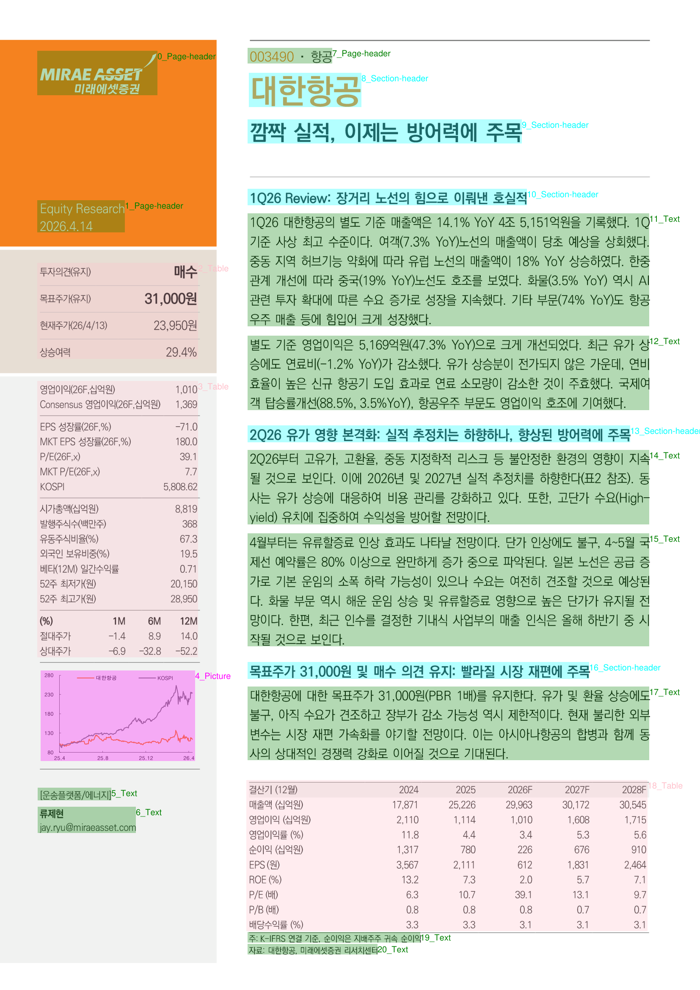

Page 2: bbox 시각화 불가 (cells 없음 or JSON fallback)


In [41]:
PREVIEW_VIZ = 2  # 시각화할 최대 페이지 수

if PROMPT_MODE in ("prompt_layout_all_en", "prompt_layout_only_en"):
    for r in page_results[:PREVIEW_VIZ]:
        cells = r.get("cells", [])
        page_no = r["page_idx"] + 1

        if not cells or r.get("filtered"):
            print(f"Page {page_no}: bbox 시각화 불가 (cells 없음 or JSON fallback)")
            continue
        try:
            viz = draw_layout_on_image(r["origin_image"], cells)
            viz.thumbnail((700, 1000))
            print(f"--- Page {page_no} 레이아웃 ({len(cells)}개 블록) ---")
            display(viz)
        except Exception as e:
            print(f"Page {page_no} 시각화 오류: {e}")
else:
    print(f"'{PROMPT_MODE}' 모드에서는 bbox 시각화가 지원되지 않습니다.")

## Cell 10. 처리 통계 요약

In [42]:
cat_counter  = Counter()
error_pages  = []
total_cells  = 0

for r in page_results:
    if r.get("error"):
        error_pages.append(r["page_idx"] + 1)
    for cell in r.get("cells", []):
        cat_counter[cell.get("category", "Unknown")] += 1
        total_cells += 1

print("=" * 50)
print("  처리 결과 요약")
print("=" * 50)
print(f"  파일명          : {input_path.name}")
print(f"  총 페이지       : {total_pages}")
print(f"  성공 페이지     : {total_pages - len(error_pages)}")
print(f"  실패 페이지     : {error_pages or '없음'}")
print(f"  총 레이아웃 블록: {total_cells}")
print(f"  MD 크기 (전체)  : {len(final_md):,} 자")
print(f"  MD 크기 (nohf)  : {len(final_md_nohf):,} 자")
print(f"  저장 위치       : {out_dir.resolve()}")

if cat_counter:
    print(f"\n  레이아웃 카테고리 분포:")
    for cat, cnt in sorted(cat_counter.items(), key=lambda x: -x[1]):
        bar = "█" * min(cnt, 35)
        print(f"    {cat:<22} {cnt:>4}  {bar}")

  처리 결과 요약
  파일명          : 2143865.pdf
  총 페이지       : 7
  성공 페이지     : 7
  실패 페이지     : 없음
  총 레이아웃 블록: 88
  MD 크기 (전체)  : 581,403 자
  MD 크기 (nohf)  : 581,135 자
  저장 위치       : /home/ubuntu/pdf-parser/dots_ocr_deploy/output/2143865

  레이아웃 카테고리 분포:
    Text                     30  ██████████████████████████████
    Table                    12  ████████████
    Page-header              11  ███████████
    Section-header           10  ██████████
    Picture                   9  █████████
    Caption                   8  ████████
    Page-footer               4  ████
    List-item                 4  ████


--- Page 1 레이아웃 (21개 블록) ---


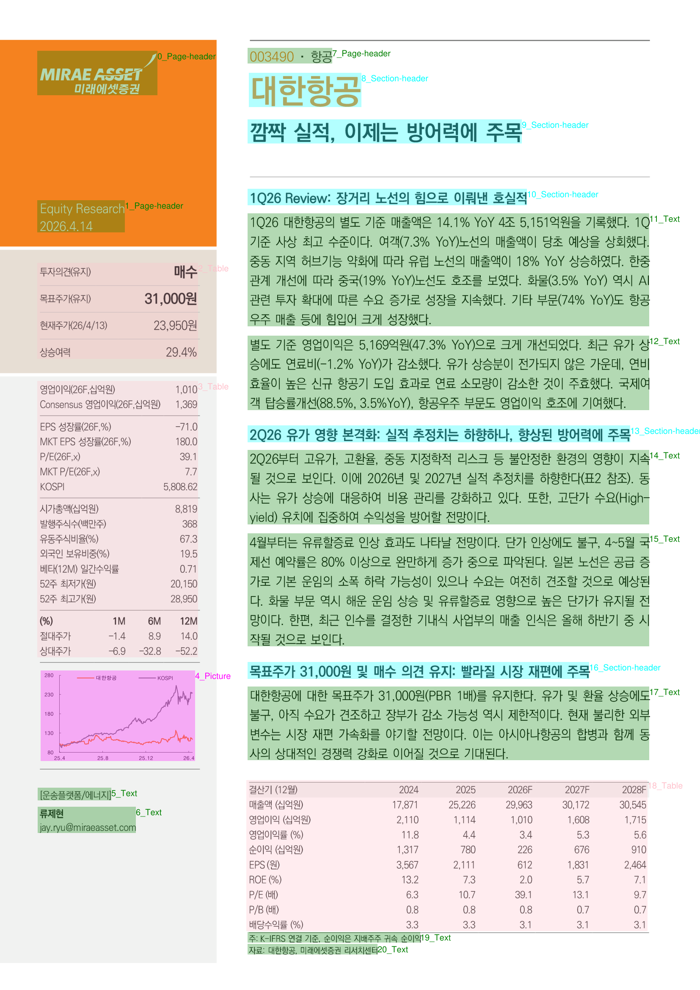

Page 2: bbox 시각화 불가 (cells 없음 or JSON fallback)
--- Page 3 레이아웃 (11개 블록) ---


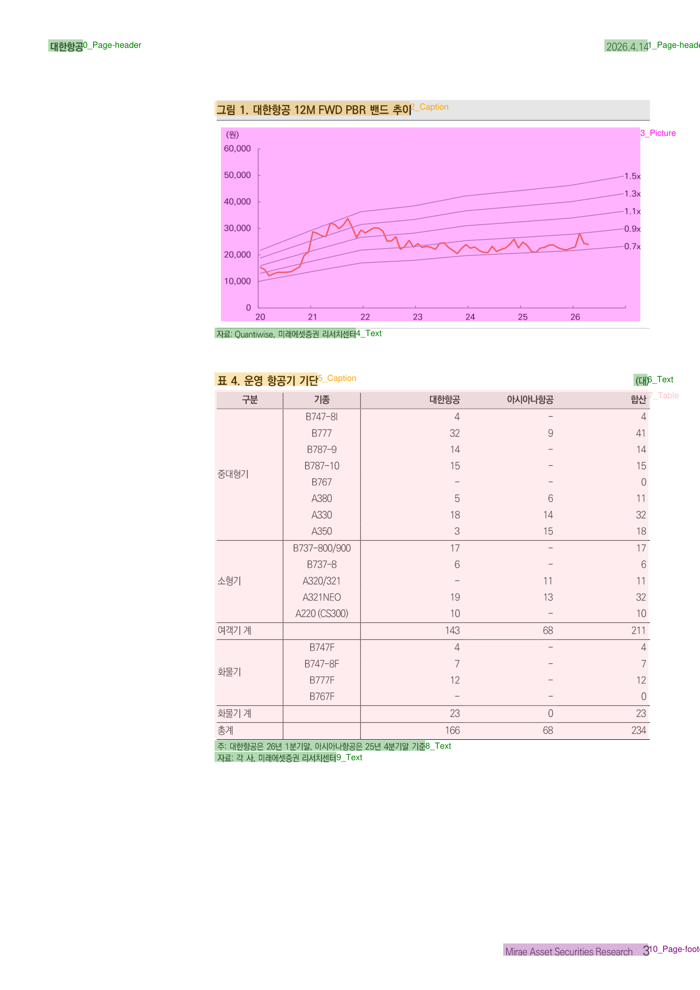

--- Page 4 레이아웃 (22개 블록) ---


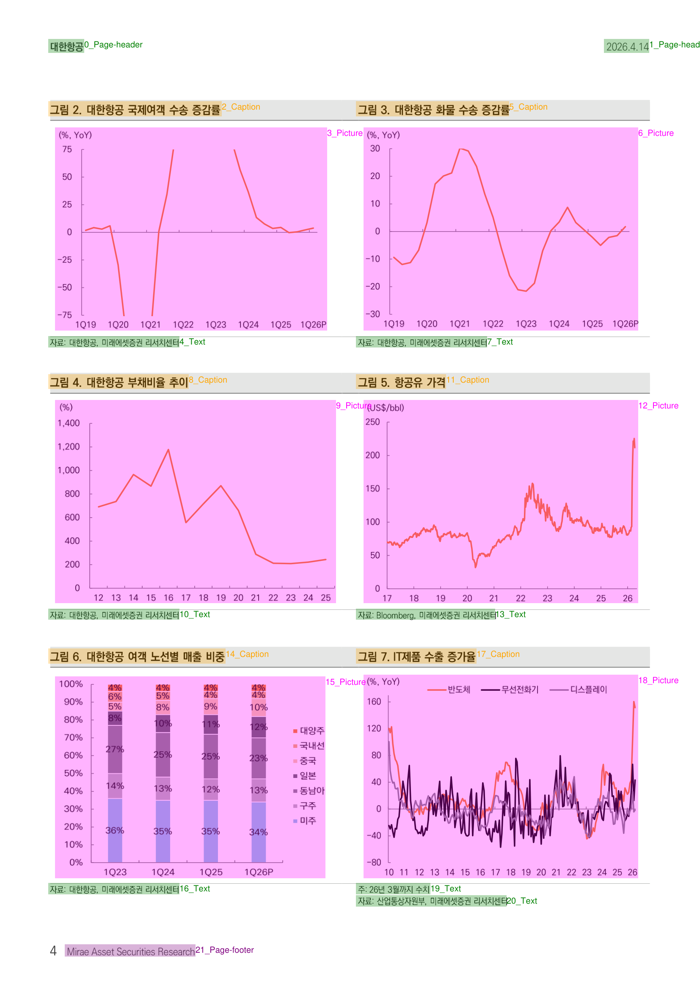

Page 5: bbox 시각화 불가 (cells 없음 or JSON fallback)
--- Page 6 레이아웃 (13개 블록) ---


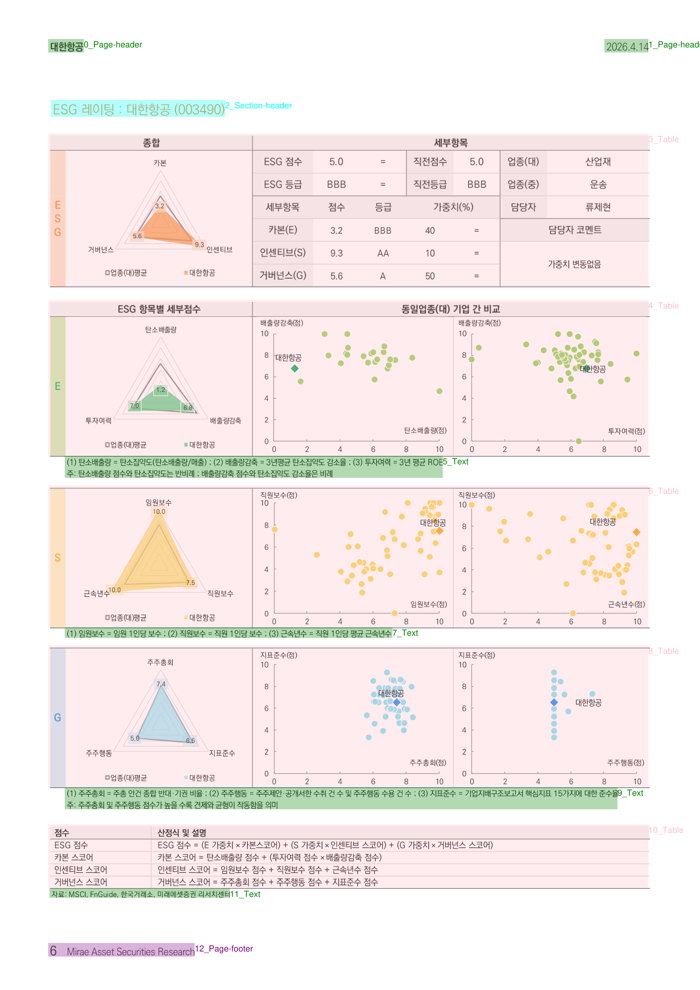

--- Page 7 레이아웃 (21개 블록) ---


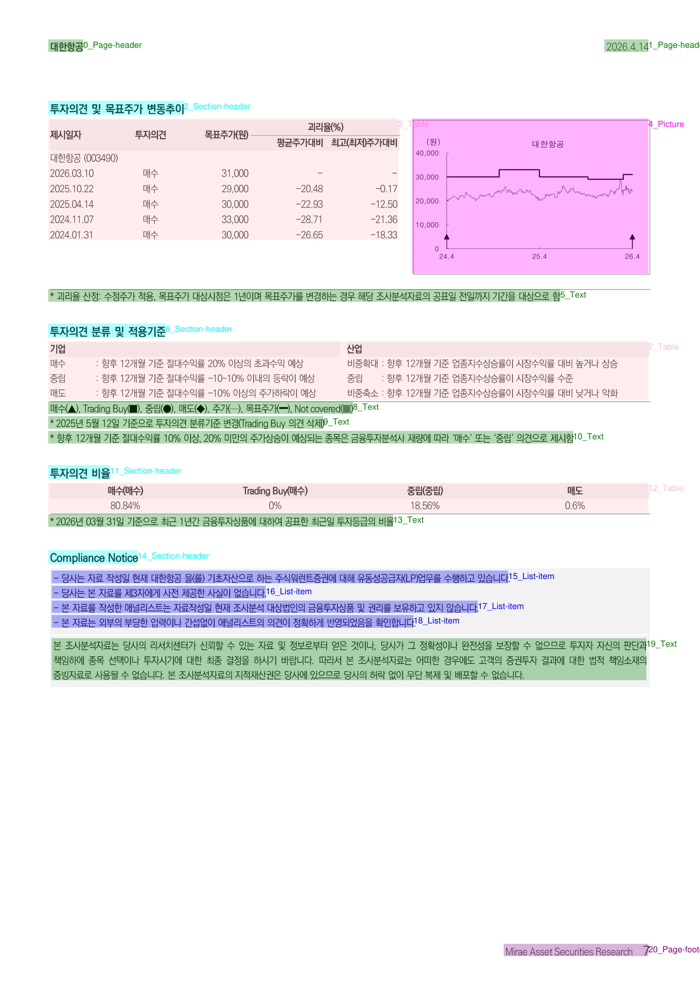

In [43]:
PREVIEW_VIZ = 2  # 시각화할 최대 페이지 수

if PROMPT_MODE in ("prompt_layout_all_en", "prompt_layout_only_en"):
    for r in page_results:
        cells = r.get("cells", [])
        page_no = r["page_idx"] + 1

        if not cells or r.get("filtered"):
            print(f"Page {page_no}: bbox 시각화 불가 (cells 없음 or JSON fallback)")
            continue
        try:
            viz = draw_layout_on_image(r["origin_image"], cells)
            viz.thumbnail((700, 1000))
            print(f"--- Page {page_no} 레이아웃 ({len(cells)}개 블록) ---")
            display(viz)
        except Exception as e:
            print(f"Page {page_no} 시각화 오류: {e}")
else:
    print(f"'{PROMPT_MODE}' 모드에서는 bbox 시각화가 지원되지 않습니다.")